# Oriented Bounding Boxes for Densely Packed Objects

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/roboflow/supervision/blob/develop/docs/notebooks/oriented-bounding-boxes.ipynb)

Many real-world objects do not line up with the image axes: boats moored along a pier, planes parked nose-in, vehicles in diagonal rows. An axis-aligned box around a rotated object is mostly background, and when objects sit close together those envelopes overlap even though the objects never touch. An oriented bounding box (OBB) follows the object's rotation, so it stays tight to the body.

This cookbook shows that difference on a marina of boats: how oriented boxes change non-max suppression and area, and how to export them as a training-ready YOLO OBB dataset.

## Install required packages

*   `supervision`: utilities for detections - annotation, NMS, dataset export. Version `0.29.0` or newer.
*   `ultralytics`: provides YOLO11-OBB, pretrained on [DOTA](https://captain-whu.github.io/DOTA/), an aerial dataset with oriented annotations.

In [1]:
%pip install -q "supervision>=0.29.0" ultralytics

In [2]:
import cv2
import numpy as np
import os
import supervision as sv
from ultralytics import YOLO

print(sv.__version__)

0.29.0


## A first oriented detection

We use `yolo11n-obb`, the smallest YOLO11 model pretrained on DOTA. Its classes include `ship`, `harbor`, `plane` and other aerial categories. We run it on Ultralytics' standard OBB sample, a top-down photo of a marina where every boat is moored at an angle (distributed in the [`ultralytics/assets`](https://github.com/ultralytics/assets) repository under the [AGPL-3.0](https://github.com/ultralytics/assets/blob/main/LICENSE) license). `Detections.from_ultralytics` reads the result, including the four rotated corners, and `OrientedBoxAnnotator` draws them. The model also outlines the piers as `harbor`, so we keep just the `ship` detections:

Boats: 172


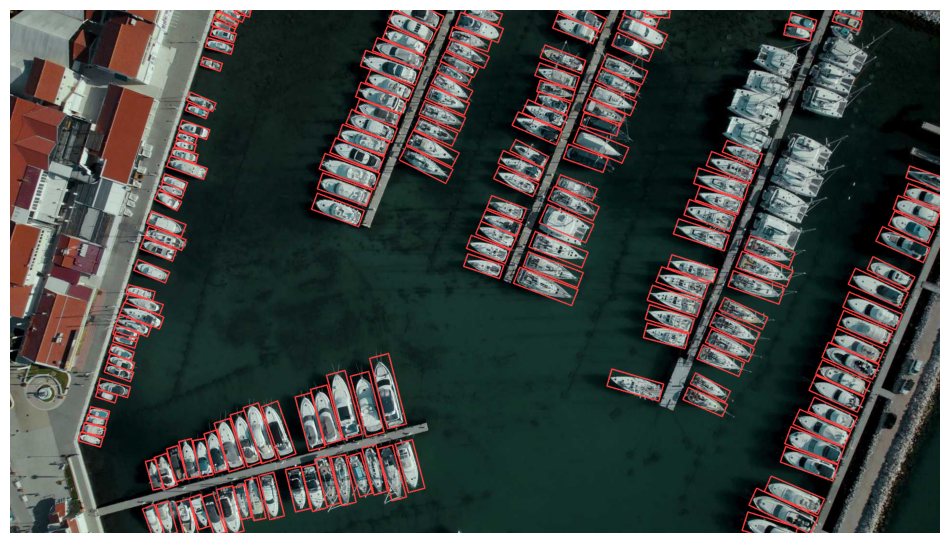

In [3]:
import urllib.request

urllib.request.urlretrieve("https://ultralytics.com/images/boats.jpg", "boats.jpg")
image = cv2.imread("boats.jpg")

model = YOLO("yolo11n-obb.pt")
detections = sv.Detections.from_ultralytics(model(image, imgsz=1024, verbose=False)[0])

# the model also tags the piers themselves as `harbor`; keep the boats
detections = detections[detections.data["class_name"] == "ship"]
print(f"Boats: {len(detections)}")

annotated = sv.OrientedBoxAnnotator(thickness=2).annotate(image.copy(), detections)
sv.plot_image(annotated, size=(12, 7))

Alongside the usual axis-aligned `xyxy` box, each detection carries the four corners of the rotated box in `detections.data["xyxyxyxy"]` as an `(N, 4, 2)` array. Those corners are what `OrientedBoxAnnotator` draws, and what supervision compares whenever they are present:

In [4]:
print("xyxy (axis-aligned):")
print(detections.xyxy[0])
print()
print('data["xyxyxyxy"] (rotated corners):')
print(detections.data["xyxyxyxy"][0])

xyxy (axis-aligned):
[     282.67      415.45      363.42      468.92]

data["xyxyxyxy"] (rotated corners):
[[     353.33      468.92]
 [     363.42      443.53]
 [     292.76      415.45]
 [     282.67      440.84]]


## Axis-aligned versus oriented boxes

Here is why the orientation matters. Zooming into one cluster of berths and drawing both box types over the same boats: the axis-aligned boxes (left) grow until they contain each angled hull, so they swell and overlap their neighbours, while the oriented boxes (right) stay tight to each boat.

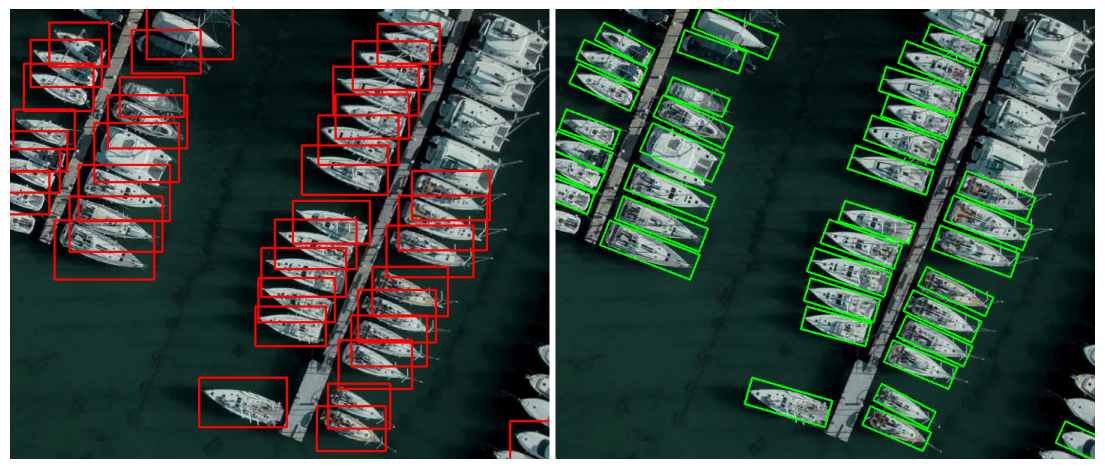

In [5]:
# zoom into one cluster of berths to compare the two box types on many boats
x1, y1, x2, y2 = 980, 250, 1700, 850
cx = (detections.xyxy[:, 0] + detections.xyxy[:, 2]) / 2
cy = (detections.xyxy[:, 1] + detections.xyxy[:, 3]) / 2
cluster = detections[(cx > x1) & (cx < x2) & (cy > y1) & (cy < y2)]

offset = np.array([x1, y1])
cluster = sv.Detections(
    xyxy=cluster.xyxy - np.tile(offset, 2),
    class_id=cluster.class_id,
    data={"xyxyxyxy": cluster.data["xyxyxyxy"] - offset},
)
crop = image[y1:y2, x1:x2]
index = sv.ColorLookup.INDEX
axis_aligned = sv.BoxAnnotator(color=sv.Color.RED, thickness=2, color_lookup=index).annotate(crop.copy(), cluster)
oriented = sv.OrientedBoxAnnotator(color=sv.Color.GREEN, thickness=2, color_lookup=index).annotate(crop.copy(), cluster)
separator = np.full((crop.shape[0], 8, 3), 255, dtype=np.uint8)
sv.plot_image(np.hstack([axis_aligned, separator, oriented]), size=(14, 6))

That overlap has a concrete cost in the two places supervision reasons about boxes.

**Non-max suppression.** `Detections.with_nms` suppresses overlapping detections. With axis-aligned envelopes, two neighbouring boats overlap enough to look like duplicates, so real boats get removed. When the oriented corners are present, supervision compares the rotated bodies instead and keeps them. At threshold=0.3 no oriented-box pair exceeds the IoU threshold — the tight hulls barely overlap — so all 172 detections survive; the difference against axis-aligned NMS shows how many real boats inflated envelopes incorrectly discard. **Footprint.** `Detections.area` returns the area of the rotated body, not the inflated envelope.

In [6]:
# axis-aligned NMS compares envelopes; oriented NMS compares the rotated bodies
axis_aligned = sv.Detections(
    xyxy=detections.xyxy.copy(),
    confidence=detections.confidence.copy(),
    class_id=detections.class_id.copy(),
)
print(f"axis-aligned NMS keeps: {len(axis_aligned.with_nms(threshold=0.3))} boats")
print(f"oriented NMS keeps:     {len(detections.with_nms(threshold=0.3))} boats")

envelope = (detections.xyxy[:, 2] - detections.xyxy[:, 0]) * (detections.xyxy[:, 3] - detections.xyxy[:, 1])
print(f"\nmedian oriented footprint: {np.median(detections.area):.0f} px^2")
print(f"median axis-aligned box:   {np.median(envelope):.0f} px^2")

axis-aligned NMS keeps: 147 boats
oriented NMS keeps:     172 boats

median oriented footprint: 2542 px^2
median axis-aligned box:   5424 px^2


## Exporting as a YOLO OBB dataset

Finally, we turn the detections into training data. `DetectionDataset.as_yolo` with `is_obb=True` writes the rotated corners in the 9-token YOLO OBB format (`class x1 y1 x2 y2 x3 y3 x4 y4`, normalized), which `ultralytics` trains on directly - handy for bootstrapping labels on a new aerial dataset:

In [7]:
os.makedirs("dataset/images", exist_ok=True)
cv2.imwrite("dataset/images/boats.jpg", image)

classes = sorted(set(detections.data["class_name"].tolist()))
name_to_id = {name: idx for idx, name in enumerate(classes)}
export = sv.Detections(
    xyxy=detections.xyxy,
    confidence=detections.confidence,
    class_id=np.array([name_to_id[name] for name in detections.data["class_name"]]),
    data=dict(detections.data),
)

dataset = sv.DetectionDataset(
    classes=classes,
    images=["dataset/images/boats.jpg"],
    annotations={"dataset/images/boats.jpg": export},
)
dataset.as_yolo(annotations_directory_path="dataset/labels", is_obb=True)

lines = open("dataset/labels/boats.txt").read().splitlines()
print(f"{len(lines)} annotations written")
print(f"first line ({len(lines[0].split())} tokens): {lines[0][:80]}...")

172 annotations written
first line (9 tokens): 0 0.18402 0.43419 0.18928 0.41068 0.15248 0.38468 0.14722 0.40819...


## Conclusion

Oriented boxes earn their keep wherever objects are rotated and packed close together. On the marina, the axis-aligned envelope of an angled boat overlaps its neighbours and overstates its footprint, while the oriented box stays tight - which is exactly what lets `with_nms` keep real boats apart, `Detections.area` measure them correctly, and `DetectionDataset.as_yolo` export them as training data. The recipe applies to any aerial or satellite workload where objects are rotated and densely packed.

## More resources

- YOLO11 OBB models: https://docs.ultralytics.com/tasks/obb/
- DOTA dataset: https://captain-whu.github.io/DOTA/
